<a href="https://colab.research.google.com/github/Alilson2/Projeto_IA/blob/main/Classifica%C3%A7%C3%A3oRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
from google.colab import drive
import seaborn as sns


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [ ]:
import os
import xarray as xr

# --- Clonar repositório se não existir ---
if not os.path.exists("Projeto_IA"):
    !git clone https://github.com/Alilson2/Projeto_IA.git
# --- Verificar se a pasta foi criada ---
if not os.path.exists("Projeto_IA"):
    raise FileNotFoundError("A pasta 'Projeto_IA' não foi encontrada. O clone pode ter falhado.")

# --- Localizar arquivos .nc ---
arquivos_nc = [f for f in os.listdir("Projeto_IA") if f.endswith(".nc")]
if not arquivos_nc:
    raise FileNotFoundError("Nenhum arquivo .nc encontrado na pasta Projeto_IA")

# --- Montar lista de caminhos ---
ARQUIVO = [os.path.join("Projeto_IA", f) for f in arquivos_nc]

# --- Função para corrigir longitude ---
def corrigir_longitude(ds):
    for coord in ["longitude", "lon"]:
        if coord in ds.coords:
            ds = ds.assign_coords({coord: ((ds[coord] + 180) % 360) - 180})
            ds = ds.sortby(coord)
    return ds

# --- Abrir arquivos com segurança (nova sintaxe) ---
try:
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='by_coords',
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )
except ValueError as e:
    print("Erro na combinação — tentando modo 'nested' (concat por tempo)...")
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='nested',
        concat_dim='valid_time',
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )

print("Dataset carregado com sucesso")

Cloning into 'Projeto_IA'...
remote: Enumerating objects: 284, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 284 (delta 58), reused 24 (delta 24), pack-reused 205 (from 1)
Receiving objects: 100% (284/284), 166.28 MiB | 34.06 MiB/s, done.
Resolving deltas: 100% (82/82), done.


/tmp/ipython-input-3648582580.py:29: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-3648582580.py:29: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(


Erro na combinação — tentando modo 'nested' (concat por tempo)...


/tmp/ipython-input-3648582580.py:38: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-3648582580.py:38: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(


Dataset carregado com sucesso


In [ ]:
df = dados.to_dataframe()
df = df.dropna()

if "valid_time" not in dados.coords:
    raise ValueError(" O dataset não contém uma coordenada temporal chamada 'valid_time'.")

# --- Converter o eixo temporal para pandas.DatetimeIndex ---
tempo = pd.to_datetime(dados["valid_time"].values)

# --- Criar DataFrame com componentes temporais ---
df_tempo = pd.DataFrame({
    "timestamp": tempo,
    "timestamp_segundos": tempo.view("int64"),   # segundos desde 1970
    "ano": tempo.year,
    "mes": tempo.month,
    "dia": tempo.day,
    "hora": tempo.hour,
    "minuto": tempo.minute,
    "segundo": tempo.second,
    "dia_semana": tempo.dayofweek,
    "dia_do_ano": tempo.dayofyear
})


dados_sorted = dados.sortby('valid_time')
dados_filtrado = dados_sorted

df_panda = dados_filtrado.to_dataframe().reset_index()
df_panda = df_panda.dropna()

df_final = pd.merge(
    df_panda,
    df_tempo,
    left_on='valid_time',
    right_on='timestamp',
    how='left'
)


df_final['longitude'] = np.round(df_final['longitude'], 1)
df_final['latitude'] = np.round(df_final['latitude'], 1)

In [ ]:
def selecionar_coordenadas(df, N_lim, S_lim, L_lim, O_lim):

    df = df[
        (df["latitude"] <= N_lim) &
        (df["latitude"] >= S_lim) &
        (df["longitude"] >= O_lim) &
        (df["longitude"] <= L_lim)
    ]

    df = df.drop_duplicates(subset=["valid_time", "latitude", "longitude"])
    return df


def calcula_vapor_umidade(df):

    t2m_c = df["t2m"] - 273.15
    d2m_c = df["d2m"] - 273.15

    es = 610.94 * np.exp(17.625 * t2m_c / (243.04 + t2m_c))
    ev = 610.94 * np.exp(17.625 * d2m_c / (243.04 + d2m_c))

    df["es"]  = es
    df["ev"]  = ev
    df["RH"]  = 100 * ev / es
    df["VPD"] = (es - ev) / 1000

    return df


def criar_dados(df):

    df["data"] = pd.to_datetime(df["valid_time"]).dt.date

    # Variáveis com estatísticas: mean, min, max
    vars_stats = ['d2m', 't2m', 'u10', 'v10', 'sp', 'es', 'ev', 'RH', 'VPD']

    # Variáveis que usam somente o último valor do dia
    vars_last = ["e", "ssrd", "sshf", "slhf", "tp"]

    g = df.groupby(["data", "latitude", "longitude"])

    resultados = {}

    for var in vars_stats:
        resultados[f"{var}_mean"] = g[var].mean()
        resultados[f"{var}_min"]  = g[var].min()
        resultados[f"{var}_max"]  = g[var].max()

    for var in vars_last:
        resultados[f"{var}_last"] = g[var].last()

    df_pixel = pd.concat(resultados, axis=1).reset_index()
    return df_pixel


def agregar_regional(df_pixel):

    df_pixel["data"] = pd.to_datetime(df_pixel["data"])
    df_pixel["mes"]  = df_pixel["data"].dt.month

    g = df_pixel.groupby("data")
    resultados = {}

    for col in df_pixel.columns:
        if col in ["data", "latitude", "longitude", "mes"]:
            continue

        if col.endswith("_last"):
            var = col.replace("_last", "")
            resultados[f"{var}_mean"] = g[col].mean()
            continue

        if "_mean" in col:
            var = col.replace("_mean", "")
            resultados[f"{var}_mean"] = g[col].mean()
            resultados[f"{var}_std"]  = g[col].std()
            continue

        if "_min" in col:
            var = col.replace("_min", "")
            resultados[f"{var}_min"]  = g[col].min()
            continue

        if "_max" in col:
            var = col.replace("_max", "")
            resultados[f"{var}_max"]  = g[col].max()
            continue

    df_regional = pd.concat(resultados, axis=1).reset_index()
    df_regional["mes"] = df_regional["data"].dt.month

    return df_regional


def pipeline(df_raw, N_lim, S_lim, L_lim, O_lim):

    df = selecionar_coordenadas(df_raw, N_lim, S_lim, L_lim, O_lim)
    df = calcula_vapor_umidade(df)
    df_daily_pixel = criar_dados(df)
    df_regional = agregar_regional(df_daily_pixel)

    return df_regional


def remover_correlacoes(X, threshold=0.90):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    return X.drop(columns=to_drop), to_drop

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
def diagnosticar_overfitting(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test, y_pred_test)
    diff = acc_train - acc_test

    cv_scores = cross_val_score(model, X_train, y_train, cv=10)
    cv_mean = cv_scores.mean()

    print("\n================ DIAGNÓSTICO DE OVERFITTING ================")
    print(f"Acurácia Treino: {acc_train:.4f}")
    print(f"Acurácia Teste:  {acc_test:.4f}")
    print(f"Diff Treino - Teste: {diff:.4f}")
    print("-------------------------------------------------------------")
    print(f"Cross-Validation (média 10 folds): {cv_mean:.4f}")
    print(f"Desvio CV: {cv_scores.std():.4f}")
    print("-------------------------------------------------------------")

    if diff < 0.05:
        status = "OK — Sem sinais de overfitting."
    elif diff < 0.10:
        status = "Overfitting leve."
    elif diff < 0.20:
        status = "Overfitting moderado."
    else:
        status = "Overfitting severo."

    print("Diagnóstico:", status)
    print("=============================================================\n")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
    cm_df = pd.DataFrame(cm,
                          index=['Actual: No Rain (0)', 'Actual: Rain (1)'],
                          columns=['Predicted: No Rain (0)', 'Predicted: Rain (1)'])
    print(cm_df)

    print(classification_report(y_test, y_pred_test,
                              target_names=['No Rain', 'Rain'],
                              labels=[0, 1],
                              zero_division=0))



def separar_dados(df_diario, limiar = 0.0005):
  X = df_diario.drop(['data', 'tp_mean'], axis=1)
  y = df_diario['tp_mean'].copy()

  ind_sem_chuva = np.where(y <= limiar)[0]
  ind_com_chuva = np.where(y > limiar)[0]

  y.iloc[ind_sem_chuva] = 0
  y.iloc[ind_com_chuva] = 1

  return X, y

def data_treino_teste(df_diario):
  ind_per = int(0.8 * len(df_diario))
  df_train = df_diario.iloc[:ind_per].copy()
  df_test  = df_diario.iloc[ind_per:].copy()

  df_train["tp_mean"] = df_train["tp_mean"].shift(-1)
  df_test["tp_mean"]  = df_test["tp_mean"].shift(-1)

  df_train = df_train.dropna().reset_index(drop=True)
  df_test  = df_test.dropna().reset_index(drop=True)
  return df_train, df_test



In [ ]:

O_lim = -46.84
L_lim = -46.36
N_lim = -23.4
S_lim = -23.74

df_panda = df_final
df_diario = pipeline(df_panda, N_lim, S_lim, L_lim, O_lim)

In [ ]:
df_train, df_test = data_treino_teste(df_diario)

X_train_raw, y_train = separar_dados(df_train)
X_test_raw,  y_test  = separar_dados(df_test)

X_train_corr, removed_corr = remover_correlacoes(X_train_raw, threshold=0.90)
X_test_corr = X_test_raw.drop(columns=removed_corr)


scaler = StandardScaler()
scaler.fit(X_train_corr)
scaler.fit(X_test_corr)

X_train = pd.DataFrame(scaler.transform(X_train_corr), columns=X_train_corr.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_corr),  columns=X_train_corr.columns)




In [ ]:
#SE FOR OTIMIZAR TIRE O # DAS LINHAS DO CODIGO

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [4, 6, 8, 10],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.5]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Treinando GridSearch...")
#grid_search.fit(X_train, y_train)

print("Melhores parâmetros:")
#print(grid_search.best_params_)

#best_model = grid_search.best_estimator_


#diagnosticar_overfitting(best_model, X_train, y_train, X_test, y_test)


Treinando GridSearch...

Melhores parâmetros:


In [ ]:
model = RandomForestClassifier(max_depth= 3, max_features= 0.5, min_samples_leaf= 3, min_samples_split= 4, n_estimators= 100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=0.5, min_samples_leaf=3,
                       min_samples_split=4, random_state=42)

In [ ]:
diagnosticar_overfitting(model, X_train, y_train, X_test, y_test)


================ DIAGNÓSTICO DE OVERFITTING ================
Acurácia Treino: 0.7849
Acurácia Teste:  0.7726
Diff Treino - Teste: 0.0123
-------------------------------------------------------------
Cross-Validation (média 10 folds): 0.7568
Desvio CV: 0.0638
-------------------------------------------------------------
Diagnóstico: OK — Sem sinais de overfitting.


Confusion Matrix:
                     Predicted: No Rain (0)  Predicted: Rain (1)
Actual: No Rain (0)                     111                   60
Actual: Rain (1)                         23                  171
              precision    recall  f1-score   support

     No Rain       0.83      0.65      0.73       171
        Rain       0.74      0.88      0.80       194

    accuracy                           0.77       365
   macro avg       0.78      0.77      0.77       365
weighted avg       0.78      0.77      0.77       365



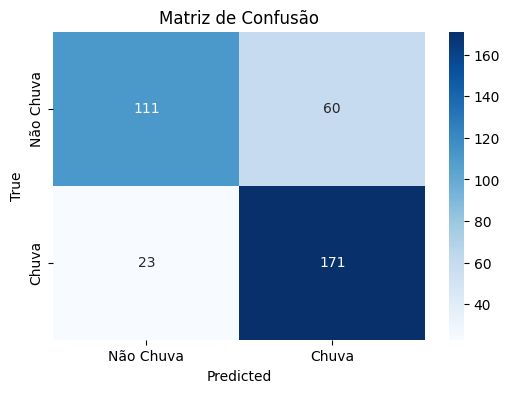

In [ ]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Matriz de Confusão")


ax.set_xticklabels(["Não Chuva", "Chuva"])
ax.set_yticklabels(["Não Chuva", "Chuva"])

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

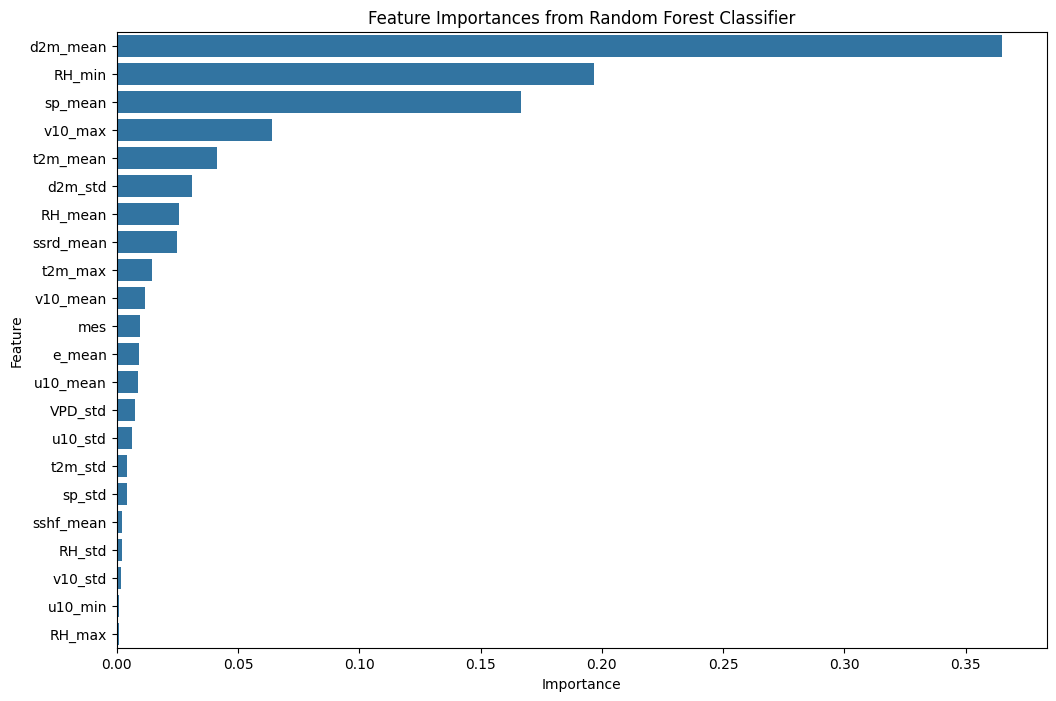

In [ ]:
importances = model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

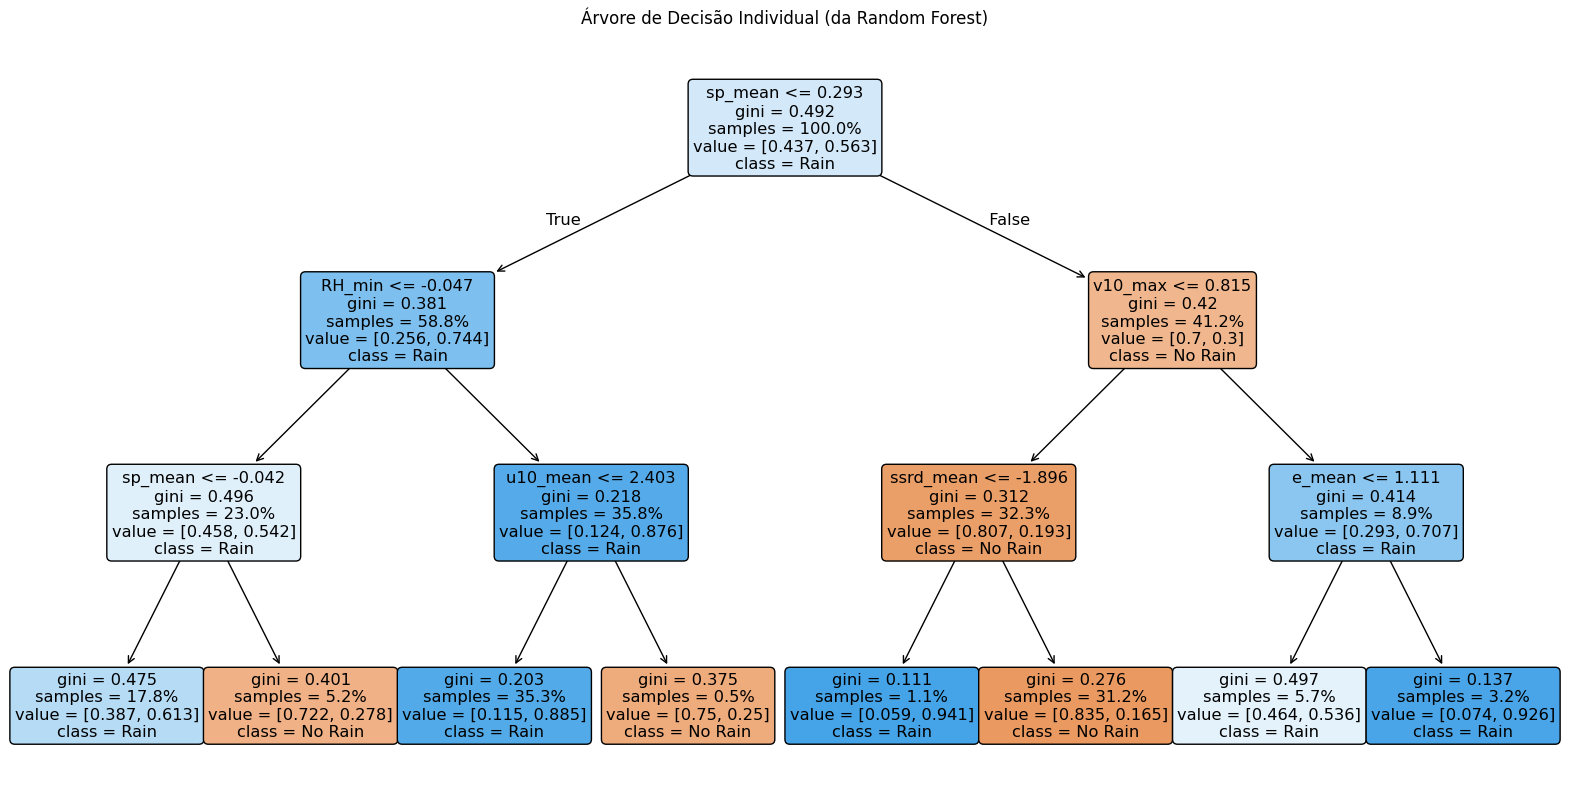

In [ ]:
from sklearn.tree import plot_tree

model = RandomForestClassifier(max_depth=3, max_features=0.5, min_samples_leaf=3, min_samples_split=4, n_estimators=100, random_state=42)

model.fit(X_train, y_train)

estimator = model.estimators_[0]

feature_names = X_train.columns.tolist()
class_names = ['No Rain', 'Rain']

plt.figure(figsize=(20, 10))
plot_tree(estimator,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          proportion=True,
          max_depth=3)
plt.title("Árvore de Decisão Individual (da Random Forest)")
plt.show()